In [1]:
%load_ext autoreload

In [2]:
%autoreload 1

In [3]:
import os, re, sys
import logging
import numpy as np
from rich import print
from rich.pretty import pprint
from rich.progress import track
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib.backends.backend_pdf import PdfPages
import hist
from hist import Hist
import mplhep as hep
import uproot
from rich.progress import Progress

parent_dir = os.path.dirname(os.path.abspath(""))
sys.path.append(parent_dir)

import cms_styles

%aimport plot_utils

In [4]:
mpl.rcParams.update({"figure.max_open_warning": 0})
hep.style.use("CMS")
np.set_printoptions(suppress=True)

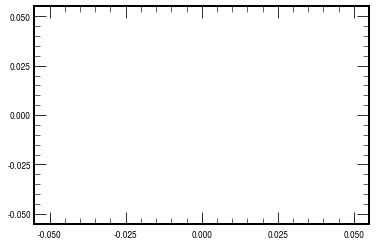

In [5]:
plt.plot()
hep.style.use(hep.style.CMS)
mpl.rcParams["figure.facecolor"] = "white"
plt.style.use(cms_styles.CMS_petroff_10)

In [6]:
logging.getLogger().setLevel(logging.ERROR)

In [7]:
plots = plot_utils.loader(
    tag=f"HLT_eff_matching_Nov2025_2018", era="2018", load_data=True
)

In [8]:
plots["QCD_Pt_MuEnrichedPt5_2018"].keys()

dict_keys(['muon3_pt', 'muon3_absdz', 'dimuon_mass', 'NUM_HLT_TripleMu_5_3_3_Mass3p8_DZ', 'DEN_HLT_TripleMu_5_3_3_Mass3p8_DZ', 'NUM_HLT_TripleMu_10_5_5_DZ', 'DEN_HLT_TripleMu_10_5_5_DZ', 'NUM_HLT_TripleMu_12_10_5', 'DEN_HLT_TripleMu_12_10_5'])

/tmp/ipykernel_1587803/84298757.py:11: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_1587803/84298757.py:11: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_1587803/84298757.py:12: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_1587803/84298757.py:12: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


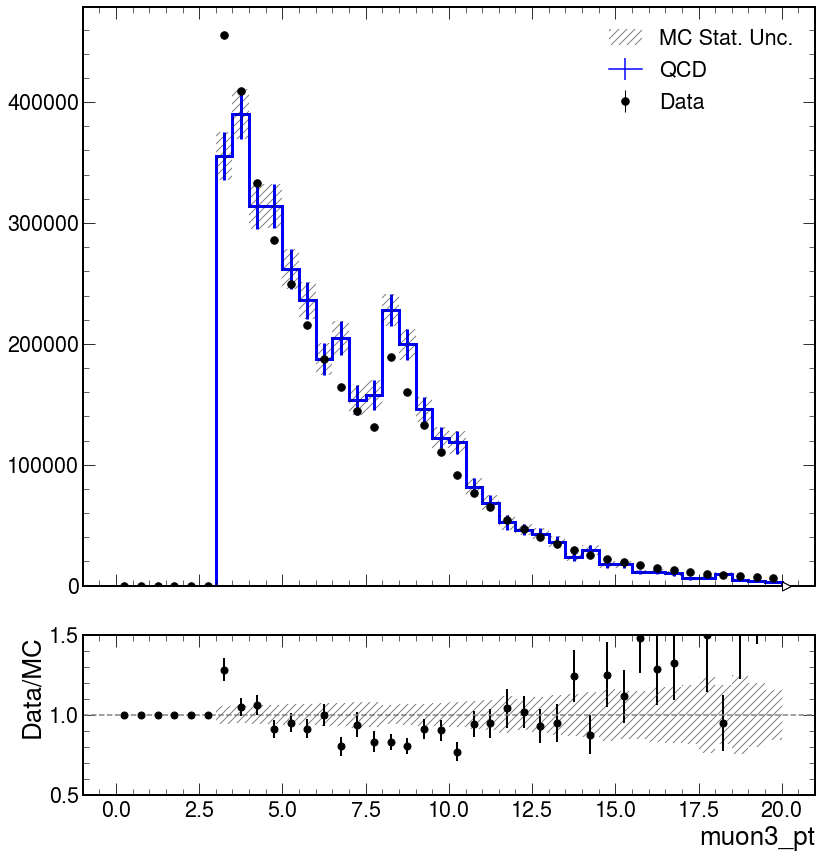

/tmp/ipykernel_1587803/84298757.py:11: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_1587803/84298757.py:11: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_1587803/84298757.py:12: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_1587803/84298757.py:12: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


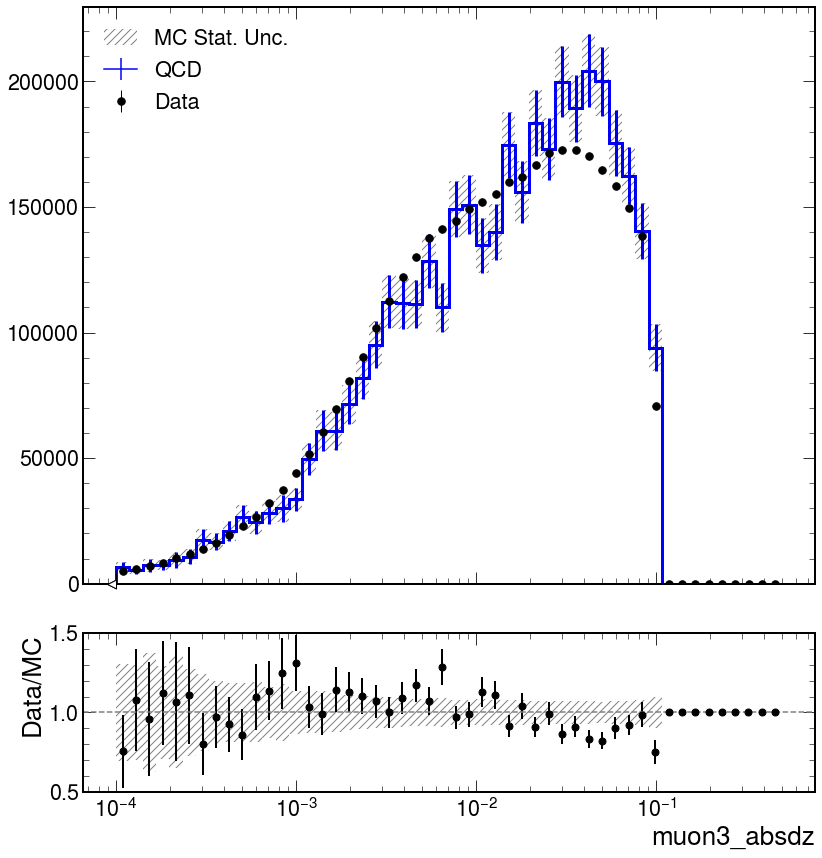

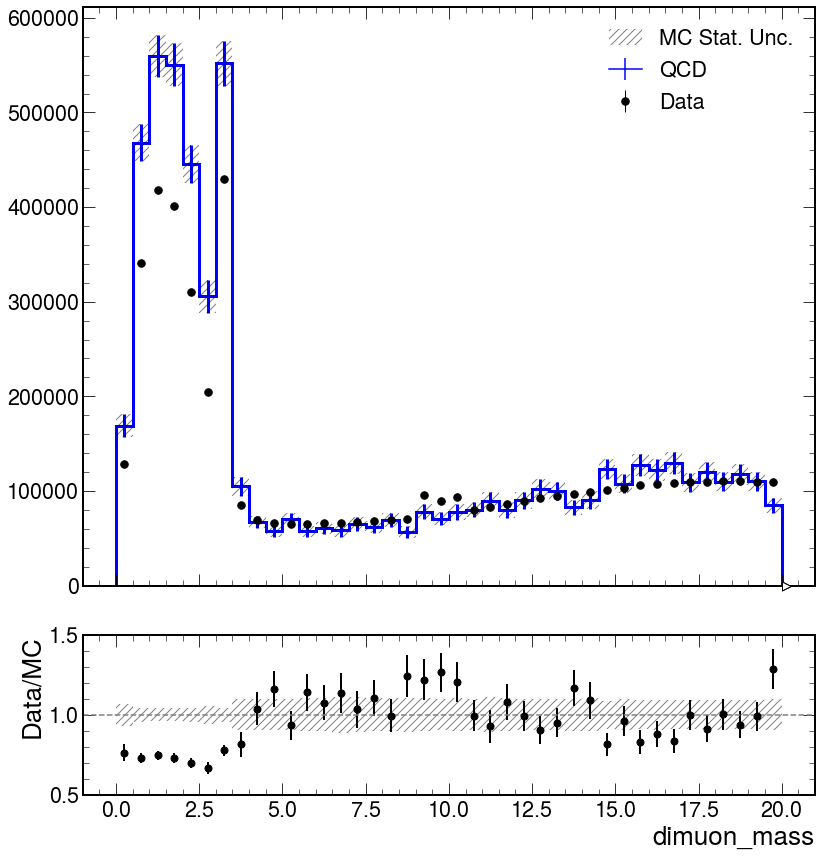

In [13]:
def plot_ratio(hist_data, hist_bkg_total, ax, x_hatch):
    ratio = np.divide(
        hist_data.values(),
        hist_bkg_total.values(),
        out=np.ones_like(hist_data.values()),
        where=hist_bkg_total.values() != 0,
    )
    ratio_err = np.where(
        hist_bkg_total.values() > 0,
        np.sqrt(
            (hist_bkg_total.values() ** -2) * (hist_data.variances())
            + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
            * (hist_bkg_total.variances())
        ),
        0,
    )
    ax.errorbar(
        hist_data.axes.centers[0],
        ratio,
        yerr=ratio_err,
        color="black",
        fmt="o",
        linestyle="none",
        markersize=7,
        lw=2,
    )

    # Draw a filled hatch area with the relative uncertainty of the MC in the ratio plot.
    mc_rel_unc = np.divide(
        np.sqrt(hist_bkg_total.variances()),
        hist_bkg_total.values(),
        out=np.zeros_like(hist_bkg_total.values()),
        where=hist_bkg_total.values() != 0,
    )
    y_hatch2 = np.vstack(
        (np.ones_like(hist_bkg_total.values()), np.ones_like(hist_bkg_total.values()))
    ).reshape((-1,), order="F")
    y_hatch2_unc = np.vstack((mc_rel_unc, mc_rel_unc)).reshape((-1,), order="F")
    ax.fill_between(
        x=x_hatch,
        y1=y_hatch2 - y_hatch2_unc,
        y2=y_hatch2 + y_hatch2_unc,
        step="pre",
        facecolor="none",
        edgecolor=(0, 0, 0, 0.5),
        linewidth=0,
        hatch="///",
    )
    ax.axhline(1, ls="--", color="gray")


for plot in ["muon3_pt", "muon3_absdz", "dimuon_mass"]:
    h_mc = plots["QCD_Pt_MuEnrichedPt5_2018"][plot]

    fig = plt.figure(figsize=(12, 12.5))
    plt.subplots_adjust(bottom=0.08, top=0.92, left=0.1, right=0.95)
    ax1 = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
    ax2 = plt.subplot2grid((4, 1), (3, 0), sharex=ax1)

    hep.histplot(
        h_mc,
        yerr=np.sqrt(h_mc.variances()),
        label="QCD",
        color="blue",
        lw=3,
        ax=ax1,
    )

    hep.histplot(
        plots[f"Data_2018"][plot],
        label=["Data"],
        histtype="errorbar",
        mec="black",
        mfc="black",
        ecolor="black",
        markersize=15,
        lw=3,
        ax=ax1,
    )

    x_hatch = np.vstack((h_mc.axes[0].edges[:-1], h_mc.axes[0].edges[1:])).reshape(
        (-1,), order="F"
    )
    y_hatch1 = np.vstack((h_mc.values(), h_mc.values())).reshape((-1,), order="F")
    y_hatch1_unc = np.vstack(
        (np.sqrt(h_mc.variances()), np.sqrt(h_mc.variances()))
    ).reshape((-1,), order="F")
    ax1.fill_between(
        x=x_hatch,
        y1=y_hatch1 - y_hatch1_unc,  # type: ignore[assign]
        y2=y_hatch1 + y_hatch1_unc,  # type: ignore[assign]
        label="MC Stat. Unc.",
        step="pre",
        facecolor="none",
        edgecolor=(0, 0, 0, 0.5),
        linewidth=0,
        hatch="///",
        zorder=2,
    )

    plot_ratio(plots[f"Data_2018"][plot], h_mc, ax2, x_hatch)

    # hep.cms.label(llabel="Preliminary", data=True, lumi=59.8, ax=ax1)

    plt.sca(ax2)
    plt.xlabel(plot)
    plt.ylim(0.5, 1.5)
    plt.ylabel("Data/MC")
    plt.setp(ax1.get_xticklabels(), visible=False)
    ax1.set_xlabel("", visible=False)

    # y_max_lin = 2 * max(plots[f"Data_{year}"][f"{region}_dimuon_mass"][mass_range, nMuon*1j].values())

    plt.sca(ax1)
    # plt.xlim(1e-1, 1e2)
    if plot == "muon3_absdz":
        plt.xscale("log")
    # if region == "CR_prompt":
    #     plt.yscale("log")
    #     plt.ylim(0, 10*y_max_lin)
    # else:
    #     plt.ylim(0, y_max_lin)
    plt.legend()
    # plt.ylabel("events")
    plt.tight_layout()
    plt.show()